In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")


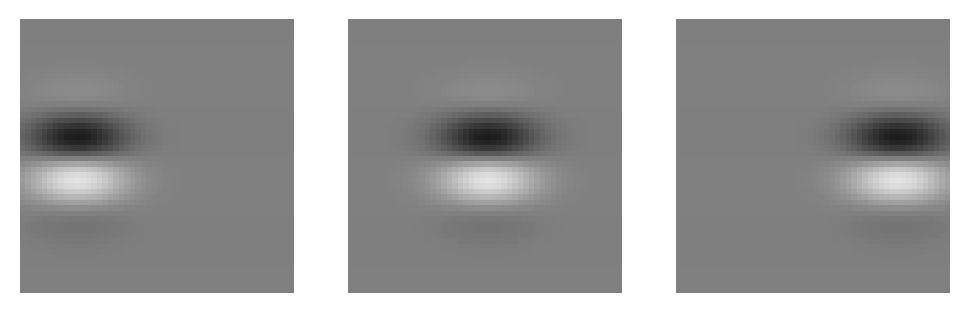

In [2]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [25],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

horizontal_gabor_set = GaborSet(**gabor_params)
horizontal_gabors =  horizontal_gabor_set.images()
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = horizontal_gabors[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

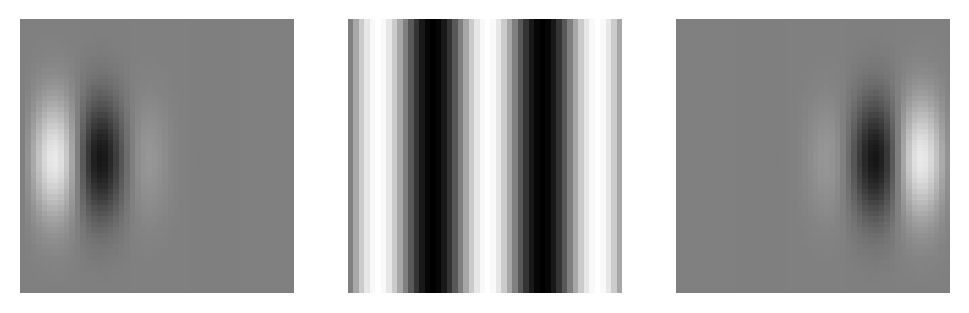

In [3]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center":  [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [0.],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30/4/50],
    "sizes_surround": [30/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

full_field_vertical_gabor_set = CenterSurround(**center_surround_params)
full_field_vertical_gabor = full_field_vertical_gabor_set.images()[0]

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(-np.sum((XX - np.array([40, 25]))**2, axis=-1) / (30/4)**2 / 2)
gauss_mask_left = np.exp(-np.sum((XX - np.array([10, 25]))**2, axis=-1) / (30/4)**2 / 2)

vertical_gabor_right = full_field_vertical_gabor * gauss_mask_right
vertical_gabor_left = full_field_vertical_gabor * gauss_mask_left

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(vertical_gabor_left, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(full_field_vertical_gabor, cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(vertical_gabor_right, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
plt.axis("off")


In [4]:
gabor_filters = np.concatenate([horizontal_gabors, np.array([vertical_gabor_left, vertical_gabor_right])], axis=0)

In [5]:
gabor_filters.shape

(5, 50, 50)

In [30]:
# np.save("/src/project/computed/gabor_filters_overlapping.npy", gabor_filters)

(-0.5, 49.5, 49.5, -0.5)

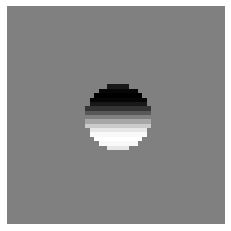

In [16]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center":  [np.pi/2],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30/4/50],
    "sizes_surround": [30/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_only_set = CenterSurround(**center_surround_params)
center_only_stimulus = center_only_set.images()[0]

plt.imshow(center_only_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

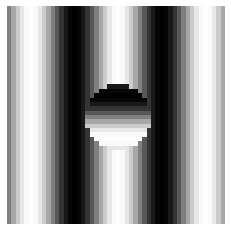

In [14]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center":  [np.pi/2],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30/4/50],
    "sizes_surround": [30/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent_surround_set = CenterSurround(**center_surround_params)
incongruent_surround_stimulus = incongruent_surround_set.images()[0]

plt.imshow(incongruent_surround_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

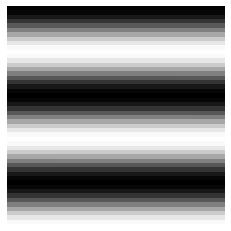

In [15]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center":  [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30/4/50],
    "sizes_surround": [30/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent_surround_set = CenterSurround(**center_surround_params)
congruent_surround_stimulus = congruent_surround_set.images()[0]

plt.imshow(congruent_surround_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [18]:
stimuli = np.array([center_only_stimulus, incongruent_surround_stimulus, congruent_surround_stimulus])

In [19]:
# np.save("/src/project/computed/gabor_filters_overlapping_stimuli.npy", stimuli)

In [20]:
# np.save("/src/project/computed/gabor_filters_overlapping_orientations.npy", np.array([np.pi/2, np.pi/2, np.pi/2, 0., 0.]))